<a href="https://colab.research.google.com/github/10decn/Lab-5/blob/main/Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5 — Spatial Filtering: Smoothing and Sharpening



---
## Theory — What is spatial filtering?

**Spatial filtering** means modifying a pixel's value based on the neighboring pixels. You slide a small matrix called a **kernel** (or mask/filter) across the image and at each position perform a mathematical operation.

<img src="https://drive.google.com/uc?export=view&id=14h_QV-crbe3ab3fcmF9d5db6eYThNFR7" width="550">

Different filters achieve different effects:

- **Low-pass** filters: make the image becomes blurrier.
- **High-pass** filters: make the image becomes sharper.

<img src="https://drive.google.com/uc?export=view&id=1v18SbrKW9XotZH2sJrW6E4U1Tc2O6DUs" width="850">

<img src="https://drive.google.com/uc?export=view&id=1DOoD9u8E-6reTMpE6oDPP6wdYGhlunGh" width="500">



<img src="https://drive.google.com/uc?export=view&id=1umT-MHWPjtNDjUf2SiS3F0BfM2v4Fg9S" width="370">


## Setup — Import libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

%matplotlib inline

## Task 1 — Unsharp Masking

**Unsharp masking** is a classic sharpening trick. Despite its confusing name, the output is a *sharper* image. The idea:

1. Blur the image → this is the "unsharp" version.
2. Subtract blurred from original.
3. Add that mask back to the original, multiplied by an `amount` → edges become sharper.


**Parameters:**
- `sigma` — how strong the blur is.
- `amount` — how much sharpening to apply.

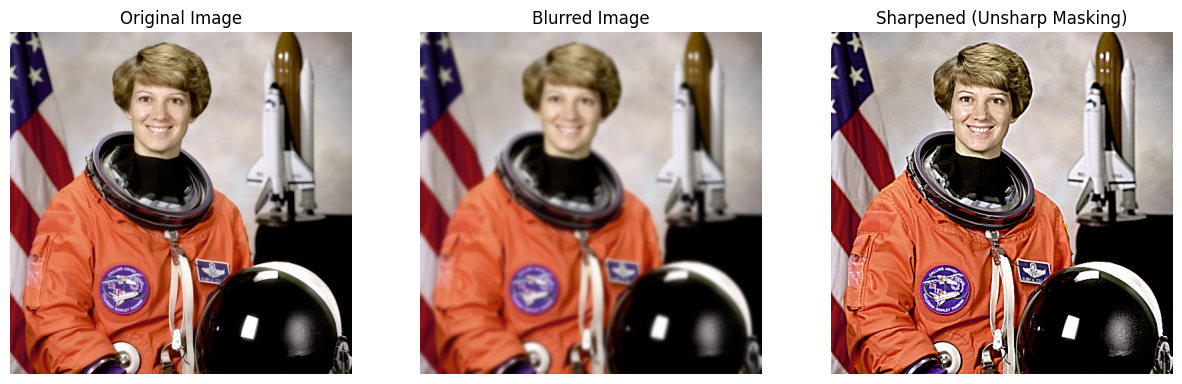

In [5]:
image = data.astronaut()

#Gaussian sigma (blur strength)
sigma = 2

#Sharpening strength
amount = 1.5

#Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

#Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

#Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

#Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);      ax[0].set_title("Original Image");              ax[0].axis("off")
ax[1].imshow(blurred);    ax[1].set_title("Blurred Image");               ax[1].axis("off")
ax[2].imshow(sharpened);  ax[2].set_title("Sharpened (Unsharp Masking)"); ax[2].axis("off")
plt.show()

---


## Assessment Task 1 — 7×7 Box Filter

A **box filter** is the simplest smoothing filter: every pixel is replaced by the **average** of the pixels in a square window around it. Every weight is equal — like a blurred "box" of influence.

A 7×7 box kernel looks like:

$$K = \frac{1}{49}\begin{bmatrix} 1 & 1 & \cdots & 1 \\ 1 & 1 & \cdots & 1 \\ \vdots & & \ddots & \vdots \\ 1 & 1 & \cdots & 1 \end{bmatrix}$$

All 49 entries are `1/49` so the weights sum to 1 (preserves average brightness).

**Effect:** Blurs the image and reduces noise. Downside: also blurs edges and produces slightly "blocky" results because of the equal weights.

Steps:
1) Build the kernel manually.
2) Apply convolution. `cv2.filter2D` is the general-purpose convolution function. It takes any kernel you give it and slides it across the image.


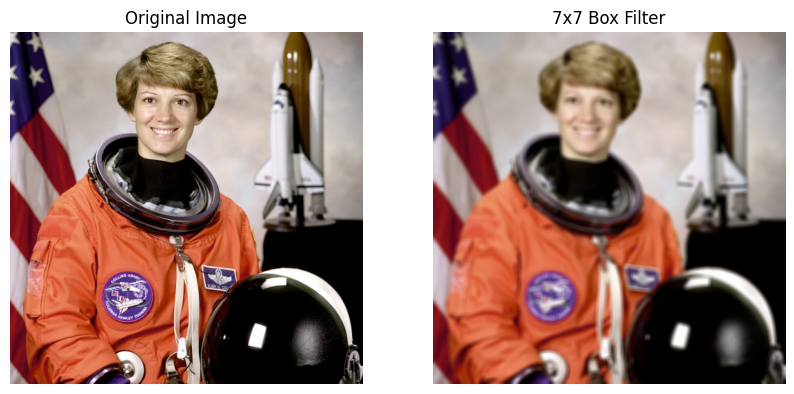

In [6]:
image = data.astronaut()
image_float = image.astype(np.float32) / 255.0

#Build the kernel
box_kernel = np.ones((7, 7), np.float32) / 49

#Apply convolution with cv2.filter2D
box_filtered = np.clip(cv2.filter2D(image_float, -1, box_kernel), 0, 1)

#plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_float); ax[0].set_title("Original Image"); ax[0].axis("off")
ax[1].imshow(box_filtered); ax[1].set_title("7x7 Box Filter");  ax[1].axis("off")
plt.show()

## Assessment Task 2 — 5×5 and 21×21 Gaussian Filters

The **Gaussian filter** is a smarter blur than the box filter. Instead of giving all pixels equal weight, it weights **nearby pixels more** than far ones, following a 2D Gaussian (bell-curve) distribution:

$$G(x,y) = \frac{1}{2\pi\sigma^2}\, e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

A 5×5 Gaussian kernel (small blur):

$$\frac{1}{256}\begin{bmatrix}1 & 4 & 6 & 4 & 1\\4 & 16 & 24 & 16 & 4\\6 & 24 & 36 & 24 & 6\\4 & 16 & 24 & 16 & 4\\1 & 4 & 6 & 4 & 1\end{bmatrix}$$

**Why prefer Gaussian over box?**
- Smoother, more natural-looking blur (no blocky artifacts)
- Preserves edges slightly better for the same blur strength
- It's the mathematically optimal tradeoff between blurring and detail preservation

**Kernel size matters:**
- Small (e.g. 5×5) → gentle blur, subtle noise reduction
- Large (e.g. 21×21) → heavy blur, washes out fine detail

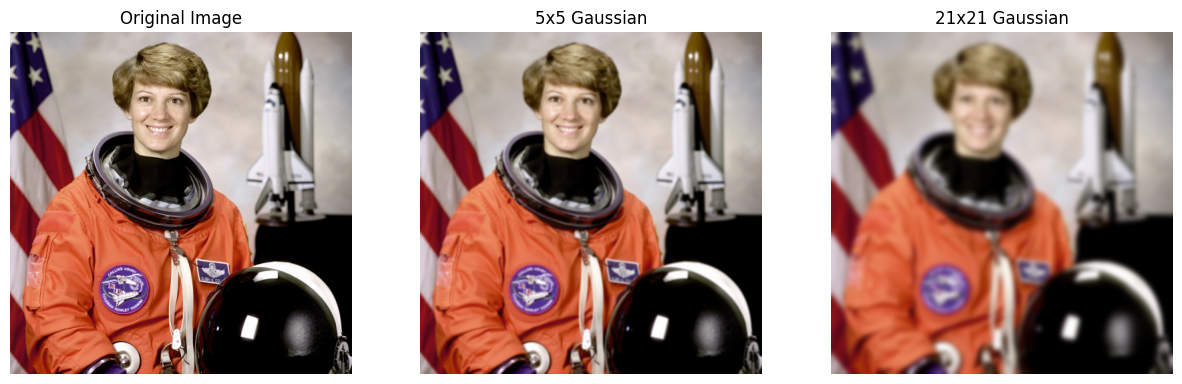

In [7]:
image_float = data.astronaut().astype(np.float32) / 255.0

#Apply 5x5 and 21x21 Gaussian blurs
gaussian_5 = cv2.GaussianBlur(image_float, (5, 5), 0)
gaussian_21 = cv2.GaussianBlur(image_float, (21, 21), 0)

#plot
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image_float); ax[0].set_title("Original Image"); ax[0].axis("off")
ax[1].imshow(gaussian_5);  ax[1].set_title("5x5 Gaussian");   ax[1].axis("off")
ax[2].imshow(gaussian_21); ax[2].set_title("21x21 Gaussian"); ax[2].axis("off")
plt.show()

## Assessment Task 3 — 3×3 Laplacian Sharpening

The **Laplacian** is a *second-order* derivative operator that responds to rapid intensity changes (edges) from any direction. A common 3×3 Laplacian kernel:

$$K = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}$$

The Laplacian's raw output is **negative around bright edges and positive around dark ones**. By itself it doesn't look like an image — it looks like an edge map.

**Sharpening trick:**

$$\text{sharp} = \text{original} - \text{laplacian}$$

Subtracting the Laplacian from the original boosts edges. The result: the image looks the same, but edges pop more.

Steps (exactly as requested in the lab):
1. Read the image
2. Convert to `float32` (Laplacian can produce negatives)
3. Apply `cv2.Laplacian()`
4. Sharpen: `np.clip(image_float - laplacian, 0, 1)`
5. Plot the three images

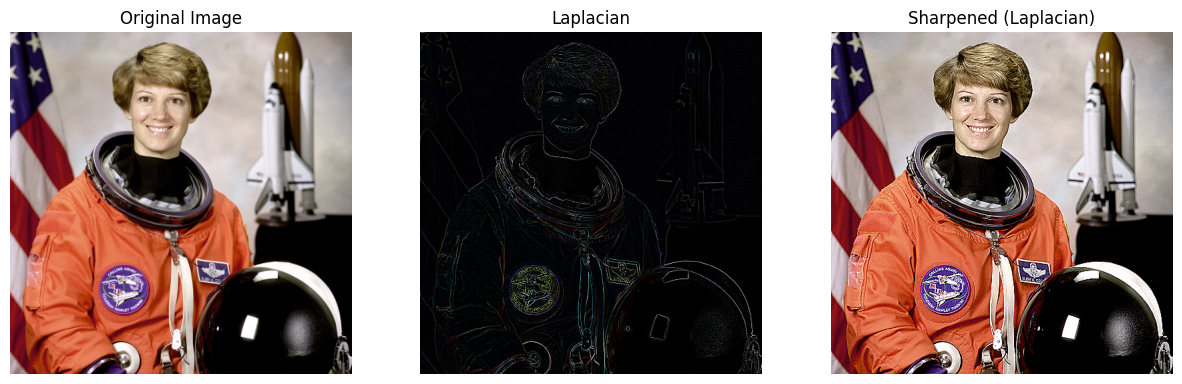

In [8]:
#Read the image
image = data.astronaut()

#Convert to float32
image_float = image.astype(np.float32) / 255.0

#Apply cv2.Laplacian()
laplacian_kernel = np.array([[0,  1, 0],
                              [1, -4, 1],
                              [0,  1, 0]], dtype=np.float32)
laplacian = cv2.filter2D(image_float, -1, laplacian_kernel)

#Sharpen
sharpened = np.clip(image_float - laplacian, 0, 1)

#plot
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image_float);              ax[0].set_title("Original Image");         ax[0].axis("off")
ax[1].imshow(np.clip(laplacian, 0, 1)); ax[1].set_title("Laplacian");               ax[1].axis("off")
ax[2].imshow(sharpened);                ax[2].set_title("Sharpened (Laplacian)");   ax[2].axis("off")
plt.show()

## Q1 — Effect of Different Box Filter Sizes
Compare 3×3, 9×9, and 15×15 box filters. Bigger kernel = stronger blur = more detail lost.

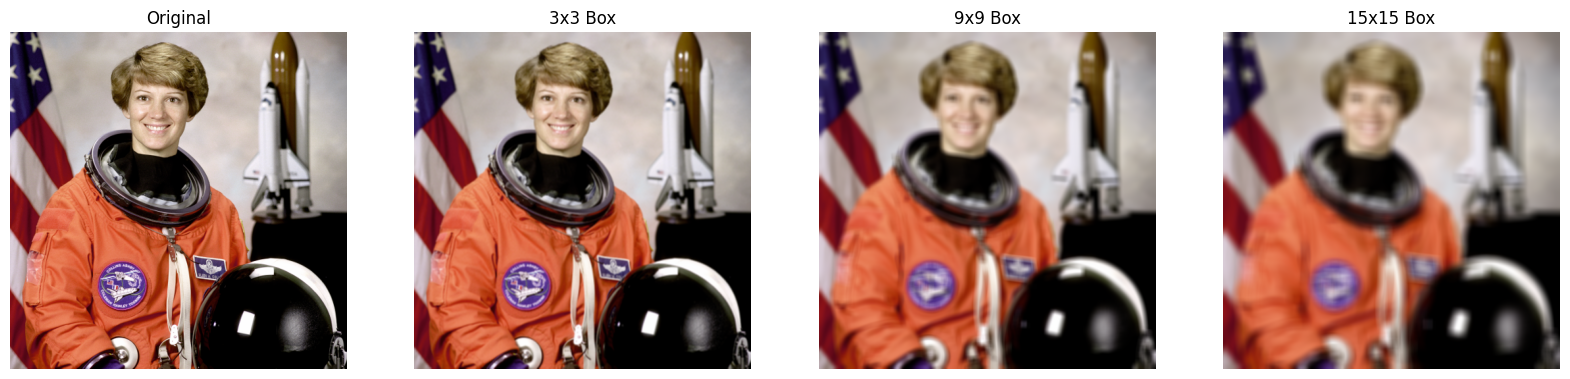

In [9]:
image_float = data.astronaut().astype(np.float32) / 255.0

sizes = [3, 9, 15]
box_results = []
for k in sizes:
    kernel = np.ones((k, k), np.float32) / (k * k)
    box_results.append(np.clip(cv2.filter2D(image_float, -1, kernel), 0, 1))

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(image_float); ax[0].set_title("Original"); ax[0].axis("off")
for i, (k, res) in enumerate(zip(sizes, box_results)):
    ax[i + 1].imshow(res); ax[i + 1].set_title(f"{k}x{k} Box"); ax[i + 1].axis("off")
plt.show()

#as the kernel grows (3x3 -> 9x9 -> 15x15) the blur gets progressively stronger and more fine detail (hair strands, eyelashes, fabric texture) is lost, while the equal-weight averaging also produces slightly "blocky" artifacts especially at 15x15

## Q2 — Median Filter: Removing Salt-and-Pepper Noise
The **median filter** replaces each pixel with the *median* of its neighborhood — not the mean. It's the best tool for removing "salt and pepper" noise (random black and white specks), because the median ignores extreme outliers.

Compare the median filter to a Gaussian blur on the same noisy image — Gaussian smears the specks, median removes them cleanly.

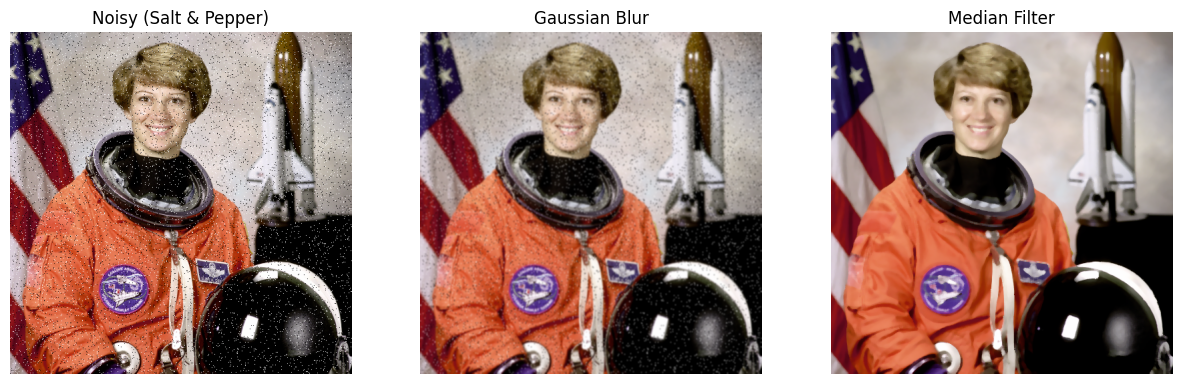

In [10]:
image = data.astronaut()
image_float = image.astype(np.float32) / 255.0

#Add salt and pepper noise
rng = np.random.default_rng(42)
prob = 0.05
noisy = image_float.copy()
mask = rng.random(image_float.shape[:2])
noisy[mask < prob / 2] = 0
noisy[mask > 1 - prob / 2] = 1

#Median filter
noisy_uint8 = (noisy * 255).astype(np.uint8)
median_filtered = cv2.medianBlur(noisy_uint8, 5).astype(np.float32) / 255.0

#Gaussian blur for comparison
gaussian_filtered = cv2.GaussianBlur(noisy, (5, 5), 0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(noisy);              ax[0].set_title("Noisy (Salt & Pepper)"); ax[0].axis("off")
ax[1].imshow(gaussian_filtered);  ax[1].set_title("Gaussian Blur");         ax[1].axis("off")
ax[2].imshow(median_filtered);    ax[2].set_title("Median Filter");        ax[2].axis("off")
plt.show()

#the Gaussian blur smears the salt-and-pepper specks into soft gray smudges but does not remove them, while the median filter eliminates the specks almost completely since the median of a neighborhood ignores the extreme black/white outliers

## Q3 — Bilateral Filter: Blurring While Keeping Edges Sharp
A normal Gaussian blur smooths everything — including edges. The **bilateral filter** is smarter: it blurs pixels only if they are close in *space* AND similar in *intensity*. Result: flat areas get smoothed, but edges stay crisp. Used in "beauty" filters, cartoon effects, and denoising.

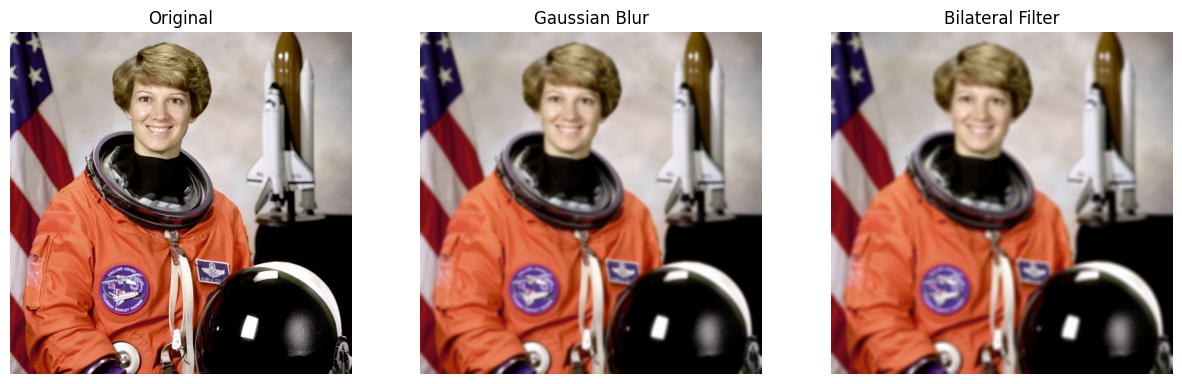

In [11]:
image = data.astronaut()
image_float = image.astype(np.float32) / 255.0

bilateral = cv2.bilateralFilter(image_float, d=9, sigmaColor=75, sigmaSpace=75)
gaussian = cv2.GaussianBlur(image_float, (9, 9), 0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image_float); ax[0].set_title("Original");        ax[0].axis("off")
ax[1].imshow(gaussian);    ax[1].set_title("Gaussian Blur");   ax[1].axis("off")
ax[2].imshow(bilateral);   ax[2].set_title("Bilateral Filter"); ax[2].axis("off")
plt.show()

#the Gaussian blur softens edges along with flat regions, while the bilateral filter smooths flat areas (like skin and background) similarly but keeps strong edges (hair outline, helmet boundary) crisp, because it only averages neighboring pixels that are also close in intensity.

---
## Summary Table

| Filter | Type | Effect | OpenCV function |
|---|---|---|---|
| **Box** | Smoothing (low-pass) | Simple average blur | `cv2.blur` or `cv2.filter2D` |
| **Gaussian** | Smoothing (low-pass) | Bell-curve weighted blur, smoother | `cv2.GaussianBlur` |
| **Median** | Smoothing (non-linear) | Removes salt-and-pepper noise | `cv2.medianBlur` |
| **Bilateral** | Smoothing (edge-preserving) | Blurs flat areas, keeps edges | `cv2.bilateralFilter` |
| **Laplacian** | Sharpening (high-pass) | Second-derivative edge enhance | `cv2.Laplacian` |
| **Unsharp mask** | Sharpening (combo) | Original + (original − blurred) | Custom (using `cv2.GaussianBlur`) |
| **Custom kernel** | Anything | Any effect you design | `cv2.filter2D` |

**Two rules to remember:**
1. For *smoothing* → use a low-pass filter (Box, Gaussian, Median, Bilateral).
2. For *sharpening* → amplify the high-frequency content (Laplacian, Unsharp mask, custom kernel with negative surround).

**End of notebook.**